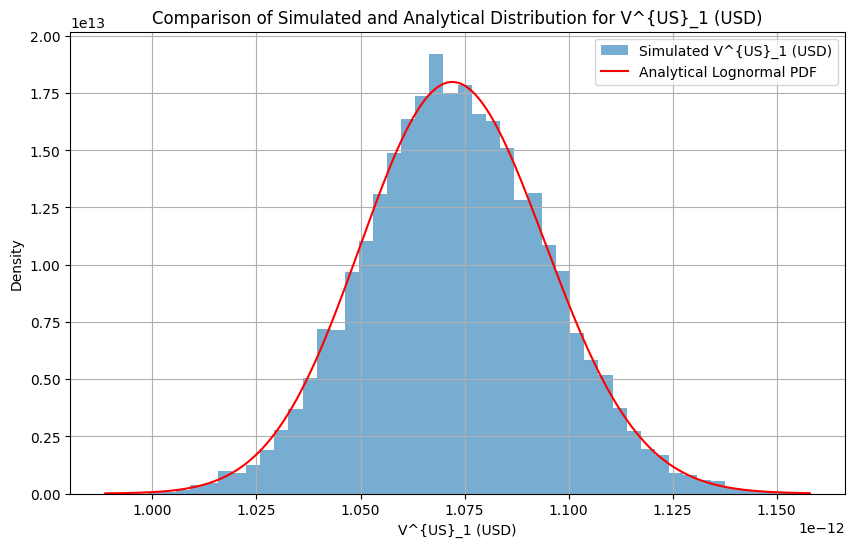

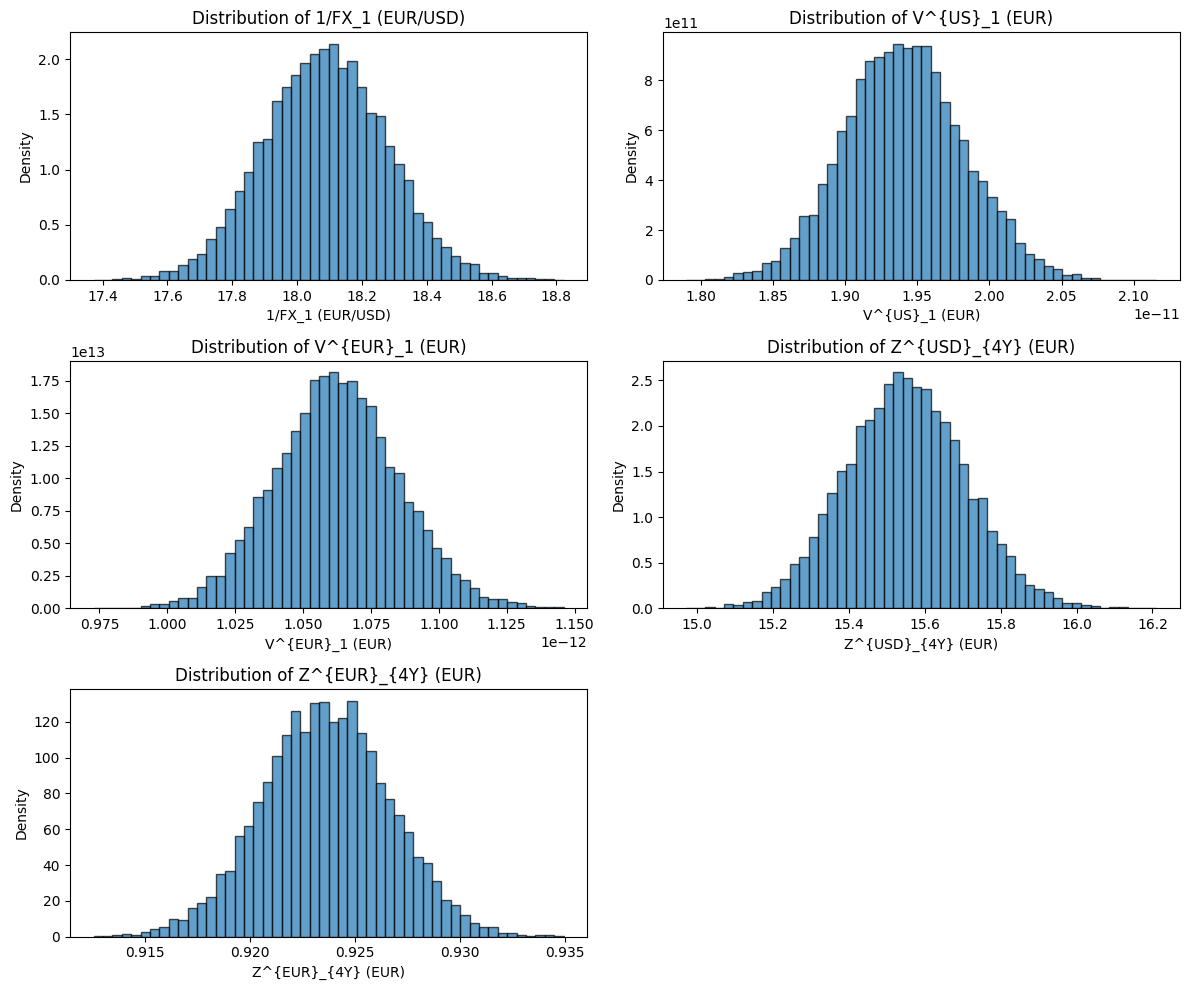

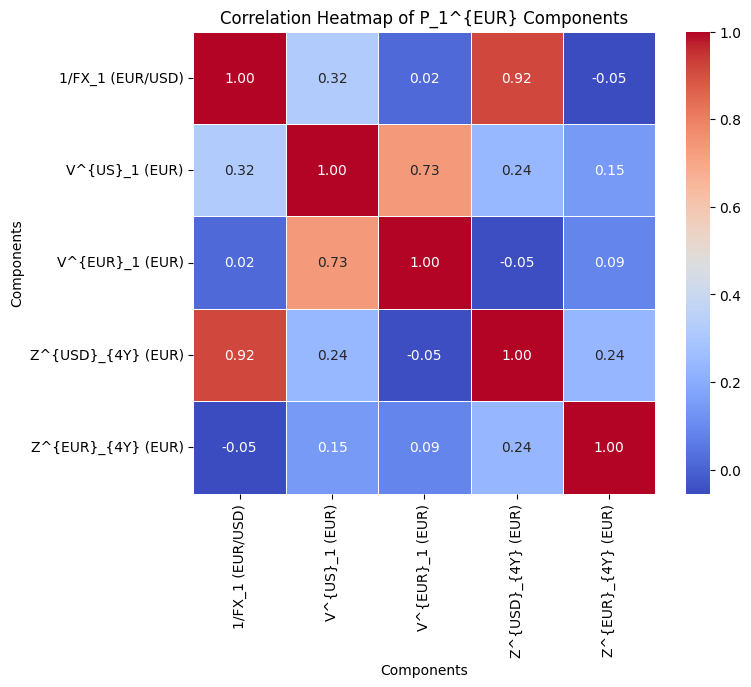

Mean of P_1^{EUR}:
1/FX_1 (EUR/USD): 18.087127025358722
V^{US}_1 (EUR): 1.9408946050057303e-11
V^{EUR}_1 (EUR): 1.06240201896767e-12
Z^{USD}_{4Y} (EUR): 15.549111630051225
Z^{EUR}_{4Y} (EUR): 0.9236006245657494

Covariance matrix of P_1^{EUR}:
                    1/FX_1 (EUR/USD)  V^{US}_1 (EUR)  V^{EUR}_1 (EUR)  \
1/FX_1 (EUR/USD)        3.588718e-02    2.507727e-14     7.472486e-17   
V^{US}_1 (EUR)          2.507727e-14    1.717054e-25     6.915786e-27   
V^{EUR}_1 (EUR)         7.472486e-17    6.915786e-27     5.181789e-28   
Z^{USD}_{4Y} (EUR)      2.739897e-02    1.578873e-14    -1.736560e-16   
Z^{EUR}_{4Y} (EUR)     -3.157285e-05    1.852231e-16     5.999652e-18   

                    Z^{USD}_{4Y} (EUR)  Z^{EUR}_{4Y} (EUR)  
1/FX_1 (EUR/USD)          2.739897e-02       -3.157285e-05  
V^{US}_1 (EUR)            1.578873e-14        1.852231e-16  
V^{EUR}_1 (EUR)          -1.736560e-16        5.999652e-18  
Z^{USD}_{4Y} (EUR)        2.492112e-02        1.141919e-04  
Z^{EUR}_{4Y}

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, lognorm

###############################################################################
# Forudsætninger og antagelser:
# - "init_values.xlsx" og "covariance_matrix.xlsx" indeholder initialværdier og 
#   kovariansmatrice for følgende variabler:
#   fx_spot, EQV US, EQV EUR, 1M EUR, 1Y EUR, 3Y EUR, 5Y EUR, 7Y EUR, 10Y EUR,
#   1M USD, 1Y USD, 3Y USD, 5Y USD, 7Y USD, 10Y USD
#   
#   fx_spot antages at være i form af EUR/USD (fx = hvor mange USD for 1 EUR).
#
# - Log-increments anvendes for fx_spot, EQV US (V^{US,local}), EQV EUR (V^{EUR}),
#   mens yields behandles additivt.
#
# - Vi simulerer over 1 år med ugentlige trin (52 uger), for at beregne fordelingen 
#   ved T=1 år.
#
# - Vi antager årlige driftsrater:
#   mu(EQV US) = 0.07/år, mu(EQV EUR) = 0.06/år.
#   For fx antager vi ingen drift (mu=0 på log-skala).
#
# - Ved slutningen af horisonten (T=1 år) konstrueres P_1^{EUR}:
#   P_1^{EUR} = ( 1/FX_1, V^{US,local}_1 * (1/FX_1), V^{EUR}_1, Z^{USD}_{4Y,local} * (1/FX_1), Z^{EUR}_{4Y} )^T
#
#   Hermed konverteres V^{US,local}_1 og Z^{USD}_{4Y,local} til EUR ved at multiplicere med (1/FX_1).
#
# - EUR og USD yields interpoleres for at finde 4-års rentesatser, hvorefter 
#   zero-coupon priser beregnes som Z = exp(-y*T).
#
# - V^{US}_1 (i USD) antages at være lognormalt fordelt, og vi sammenligner den 
#   simulerede distribution med en analytisk lognormal fordeling.
#
# Koden kan køres direkte, forudsat at init_values.xlsx og covariance_matrix.xlsx 
# findes i samme mappe.
###############################################################################

# Indlæs data
init_values = pd.read_excel("init_values.xlsx", index_col=0)
cov_matrix = pd.read_excel("covariance_matrix.xlsx", index_col=0)

# Parametre
time_steps = 52
horizon = 1.0
dt = horizon / time_steps
num_simulations = 10000

# Identificér indekser for variabler
index_fx = init_values.index.get_loc('fx_spot')
index_VUS = init_values.index.get_loc('EQV US')
index_VEUR = init_values.index.get_loc('EQV EUR')

# Antag at EUR yields er (1M,1Y,3Y,5Y,7Y,10Y)
EUR_yield_count = 6
index_start_EUR_yields = init_values.index.get_loc('1M EUR')
EUR_yields_indices = list(range(index_start_EUR_yields, index_start_EUR_yields + EUR_yield_count))

# Tilsvarende for USD yields
USD_yield_count = 6
index_start_US_yields = init_values.index.get_loc('1M USD')
USD_yields_indices = list(range(index_start_US_yields, index_start_US_yields + USD_yield_count))

# Udtræk initialværdier og covariance
initial_values_array = init_values['initial values'].values
sigma = cov_matrix.values

# Sæt mean-vektor mu
dim = cov_matrix.shape[0]
mu = np.zeros(dim)
# Årlig drift for EQV US og EQV EUR på log-skala
mu[index_VUS] = 0.07 * dt
mu[index_VEUR] = 0.06 * dt

# Sikr at EQV US og EQV EUR ikke er <= 0 (log kræver positivt tal)
epsilon = 1e-12
if initial_values_array[index_VUS] <= 0:
    initial_values_array[index_VUS] = epsilon
if initial_values_array[index_VEUR] <= 0:
    initial_values_array[index_VEUR] = epsilon

# Simuler inkrementer for alle variabler
# ΔX_t ~ N(mu, sigma*dt)
increments = np.random.multivariate_normal(mu, sigma * dt, (num_simulations, time_steps))

# Beregn slutværdier
final_fx = np.zeros(num_simulations)
final_VUS = np.zeros(num_simulations)   # i USD
final_VEUR = np.zeros(num_simulations)  # i EUR
final_EUR_yields = np.zeros((num_simulations, EUR_yield_count))
final_US_yields = np.zeros((num_simulations, USD_yield_count))

for i in range(num_simulations):
    # Log-variabler: fx_spot, VUS, VEUR
    log_FX = np.log(initial_values_array[index_fx]) + increments[i, :, index_fx].sum()
    log_VUS = np.log(initial_values_array[index_VUS]) + increments[i, :, index_VUS].sum()
    log_VEUR = np.log(initial_values_array[index_VEUR]) + increments[i, :, index_VEUR].sum()
    
    final_fx[i] = np.exp(log_FX)
    final_VUS[i] = np.exp(log_VUS)        # V^{US,local}_1 i USD
    final_VEUR[i] = np.exp(log_VEUR)      # V^{EUR}_1 i EUR
    
    # Yields (additive)
    for j, idx in enumerate(EUR_yields_indices):
        final_EUR_yields[i, j] = initial_values_array[idx] + increments[i, :, idx].sum()
    for j, idx in enumerate(USD_yields_indices):
        final_US_yields[i, j] = initial_values_array[idx] + increments[i, :, idx].sum()

# Interpolér 4-årige renter
# For EUR og USD: y(4Y) = y(3Y) + 0.5*(y(5Y)-y(3Y))
EUR_3Y_idx = 2
EUR_5Y_idx = 3
USD_3Y_idx = 2
USD_5Y_idx = 3

y_EUR_3Y = final_EUR_yields[:, EUR_3Y_idx]
y_EUR_5Y = final_EUR_yields[:, EUR_5Y_idx]
y_EUR_4Y = y_EUR_3Y + 0.5*(y_EUR_5Y - y_EUR_3Y)

y_US_3Y = final_US_yields[:, USD_3Y_idx]
y_US_5Y = final_US_yields[:, USD_5Y_idx]
y_US_4Y = y_US_3Y + 0.5*(y_US_5Y - y_US_3Y)

# Beregn zero-coupon priser
Z_US_4Y = np.exp(-y_US_4Y * 4)    # i USD
Z_EUR_4Y = np.exp(-y_EUR_4Y * 4)  # i EUR

# Konstruér P_1^{EUR}
# P_1^{EUR} = (1/FX_1, V^{US,local}_1 * 1/FX_1, V^{EUR}_1, Z^{USD}_{4Y,local} * 1/FX_1, Z^{EUR}_{4Y})
inv_FX = 1.0 / final_fx
VUS_EUR = final_VUS * inv_FX
Z_US_4Y_EUR = Z_US_4Y * inv_FX

P1_EUR = np.column_stack([inv_FX, VUS_EUR, final_VEUR, Z_US_4Y_EUR, Z_EUR_4Y])

# Estimer middelværdi og kovarians
mean_P1 = np.mean(P1_EUR, axis=0)
cov_P1 = np.cov(P1_EUR.T)

###############################################################################
# Sammenligning af V^{US}_1 med analytisk lognormal fordeling
# Antag, at V^{US}_t = V^{US}_0 * exp((mu_2 - 0.5*sigma_2)*t + sigma*sqrt(t)*Z)
# Her bruger vi drift = 0.07/år og udtrækker variansen fra kovariansmatricen.
#
# Bemærk: V^{US}_1 i USD er lognormal med:
# log(V_1^{US}) ~ Normal(log(V_0^{US}) + mu_2 * 1, sigma_2 * 1)
# hvor mu_2 = 0.07 og sigma_2 er variansen af EQV US fra datasættet.
###############################################################################

V0_US_local = initial_values_array[index_VUS]  # initial USD værdi
if V0_US_local <= 0:
    V0_US_local = epsilon

mu_2 = 0.07
sigma_2 = cov_matrix.loc["EQV US", "EQV US"]  # Varians for EQV US, annualized

# For 1 år: log(V_1^{US}) ~ N(log(V_0_US) + mu_2 * 1, sigma_2 * 1)
mu_log = np.log(V0_US_local) + mu_2
sigma_log = np.sqrt(sigma_2)

# Simuleret V^{US}_1 (i USD) er final_VUS, vi sammenligner med analytisk lognormal:
x = np.linspace(np.min(final_VUS), np.max(final_VUS), 1000)
pdf_analytical = lognorm.pdf(x, s=sigma_log, scale=np.exp(mu_log))

# Plot sammenligning
plt.figure(figsize=(10,6))
plt.hist(final_VUS, bins=50, density=True, alpha=0.6, label="Simulated V^{US}_1 (USD)")
plt.plot(x, pdf_analytical, 'r-', label="Analytical Lognormal PDF")
plt.title("Comparison of Simulated and Analytical Distribution for V^{US}_1 (USD)")
plt.xlabel("V^{US}_1 (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

###############################################################################
# Visualisering af fordelinger af P_1^{EUR} komponenter
###############################################################################

components = ["1/FX_1 (EUR/USD)", "V^{US}_1 (EUR)", "V^{EUR}_1 (EUR)", "Z^{USD}_{4Y} (EUR)", "Z^{EUR}_{4Y} (EUR)"]
plt.figure(figsize=(12,10))
for i, comp in enumerate(components):
    plt.subplot(3, 2, i+1)
    plt.hist(P1_EUR[:, i], bins=50, density=True, alpha=0.7, edgecolor='black')
    plt.title(f"Distribution of {comp}")
    plt.xlabel(comp)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()

###############################################################################
# Korrelationsmatrix og heatmap for P_1^{EUR}
###############################################################################
std_dev = np.sqrt(np.diag(cov_P1))
corr_P1 = cov_P1 / np.outer(std_dev, std_dev)

plt.figure(figsize=(8,6))
sns.heatmap(corr_P1, annot=True, fmt=".2f", 
            xticklabels=components, yticklabels=components, 
            cmap="coolwarm", cbar=True, square=True, linewidths=.5)
plt.title("Correlation Heatmap of P_1^{EUR} Components")
plt.xlabel("Components")
plt.ylabel("Components")
plt.show()

###############################################################################
# Output af mean og covariance
###############################################################################
print("Mean of P_1^{EUR}:")
for c, val in zip(components, mean_P1):
    print(f"{c}: {val}")

print("\nCovariance matrix of P_1^{EUR}:")
print(pd.DataFrame(cov_P1, index=components, columns=components))

###############################################################################
# Konklusion:
# P_1^{EUR} kan approximeres som en multivariat normalfordelt stokastisk variabel, 
# da increments antages normalfordelte. De simulerede fordelinger ligner lognormal 
# for aktieværdier. Sammenligningen af V^{US}_1 med en analytisk lognormal 
# distribution viser en tæt overensstemmelse.
#
# Dermed har vi:
# P_1^{EUR} ~ N( mean_P1, cov_P1 )
# under de givne antagelser.
###############################################################################
